<a href="https://colab.research.google.com/github/nightlurkr/FinalProjectAI-CekFresh/blob/main/fp_ai_kel8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ryanadya","key":"c63fd2418a030d2fd484e87843e76a1b"}'}

In [2]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle API siap digunakan!")

Kaggle API siap digunakan!


In [3]:
# Download dataset 1: sriramr (pisang & jeruk)
!kaggle datasets download -d sriramr/fruits-fresh-and-rotten-for-classification -p /content/datasets/sriramr

# Download dataset 2: raghavrpotdar (tomat)
!kaggle datasets download -d raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables -p /content/datasets/raghavrpotdar

print("Download selesai!")

Dataset URL: https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification
License(s): unknown
100% 3.58G/3.58G [00:21<00:00, 181MB/s]

Dataset URL: https://www.kaggle.com/datasets/raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables
License(s): CC0-1.0
100% 1.41G/1.41G [00:12<00:00, 117MB/s]

Download selesai!


In [4]:
import zipfile

with zipfile.ZipFile('/content/datasets/sriramr/fruits-fresh-and-rotten-for-classification.zip', 'r') as z:
    z.extractall('/content/datasets/sriramr/')

with zipfile.ZipFile('/content/datasets/raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables.zip', 'r') as z:
    z.extractall('/content/datasets/raghavrpotdar/')

print("Ekstrak selesai!")

Ekstrak selesai!


In [5]:
# Melihat isi folder hasil ekstrak untuk memastikan strukturnya benar
for dataset in ['sriramr', 'raghavrpotdar']:
    print(f"\n=== Struktur {dataset} ===")
    for root, dirs, files in os.walk(f'/content/datasets/{dataset}'):
        level = root.replace(f'/content/datasets/{dataset}', '').count(os.sep)
        if level < 3:
            indent = ' ' * 2 * level
            print(f'{indent}{os.path.basename(root)}/')


=== Struktur sriramr ===
sriramr/
  dataset/
    train/
    test/
    dataset/

=== Struktur raghavrpotdar ===
raghavrpotdar/
  stale_apple/
  fresh_capsicum/
  fresh_tomato/
  stale_banana/
  fresh_apple/
  stale_orange/
  fresh_bitter_gourd/
  fresh_banana/
  fresh_orange/
  stale_capsicum/
  stale_bitter_gourd/
  stale_tomato/


### EDA (Exploratory Data Analysis)

Melihat struktur lengkap kedua dataset

In [6]:
print("=== ISI DATASET SRIRAMR ===")
for item in sorted(os.listdir('/content/datasets/sriramr')):
    print(f"  {item}")

print("\n=== ISI DATASET RAGHAVRPOTDAR ===")
for item in sorted(os.listdir('/content/datasets/raghavrpotdar')):
    print(f"  {item}")

=== ISI DATASET SRIRAMR ===
  dataset
  fruits-fresh-and-rotten-for-classification.zip

=== ISI DATASET RAGHAVRPOTDAR ===
  ImageLabels.txt
  fresh-and-stale-images-of-fruits-and-vegetables.zip
  fresh_apple
  fresh_banana
  fresh_bitter_gourd
  fresh_capsicum
  fresh_orange
  fresh_tomato
  stale_apple
  stale_banana
  stale_bitter_gourd
  stale_capsicum
  stale_orange
  stale_tomato


untuk Raghavpotdae langsung terlihat struktur foldernya tapi untuk dataset siramr masih ada didalam folder `dataset` jadi selanjutnya mencoba untuk melihat isi dari folder dataset di sriramr.

In [7]:
print("=== ISI FOLDER DATASET/SRIRAMR ===")
for item in sorted(os.listdir('/content/datasets/sriramr/dataset')):
    print(f"  {item}")

=== ISI FOLDER DATASET/SRIRAMR ===
  dataset
  test
  train


masih ada subfolder lagi dan terlihat bahwa sriramr strukturnya `dataset/dataset/train` dan `dataset/dataset/test` selanjutnya melihat satu level lagi untuk melihat isi dari folder train dan test di sriramr.

In [8]:
print("=== ISI FOLDER TRAIN ===")
for item in sorted(os.listdir('/content/datasets/sriramr/dataset/dataset/train')):
    print(f"  {item}")

print("\n=== ISI FOLDER TEST ===")
for item in sorted(os.listdir('/content/datasets/sriramr/dataset/dataset/test')):
    print(f"  {item}")

=== ISI FOLDER TRAIN ===
  freshapples
  freshbanana
  freshoranges
  rottenapples
  rottenbanana
  rottenoranges

=== ISI FOLDER TEST ===
  freshapples
  freshbanana
  freshoranges
  rottenapples
  rottenbanana
  rottenoranges


#### **Menghitung jumlah gambar per kelas di kedua dataset**

ini untuk mendeteksi jika ada class imbalance (ketidakseimbangan jumlah data antar kelas) sebelum proses training.

In [9]:
sriramr_base_train = '/content/datasets/sriramr/dataset/dataset/train'
sriramr_base_test  = '/content/datasets/sriramr/dataset/dataset/test'
raghavrpotdar_base = '/content/datasets/raghavrpotdar'

# Folder yang relevan dari masing-masing dataset
sriramr_train_folders = [
    'freshbanana', 'rottenbanana',
    'freshoranges', 'rottenoranges'
]
sriramr_test_folders = [
    'freshbanana', 'rottenbanana',
    'freshoranges', 'rottenoranges'
]
raghavrpotdar_folders = [
    'fresh_tomato', 'stale_tomato'
]

print("=== JUMLAH GAMBAR SRIRAMR (Train) ===")
for folder in sriramr_train_folders:
    path = os.path.join(sriramr_base_train, folder)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder}: {count} gambar")

print("\n=== JUMLAH GAMBAR SRIRAMR (Test) ===")
for folder in sriramr_test_folders:
    path = os.path.join(sriramr_base_test, folder)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder}: {count} gambar")

print("\n=== JUMLAH GAMBAR RAGHAVRPOTDAR (Tomat) ===")
for folder in raghavrpotdar_folders:
    path = os.path.join(raghavrpotdar_base, folder)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder}: {count} gambar")


=== JUMLAH GAMBAR SRIRAMR (Train) ===
  freshbanana: 1581 gambar
  rottenbanana: 2224 gambar
  freshoranges: 1466 gambar
  rottenoranges: 1595 gambar

=== JUMLAH GAMBAR SRIRAMR (Test) ===
  freshbanana: 381 gambar
  rottenbanana: 530 gambar
  freshoranges: 388 gambar
  rottenoranges: 403 gambar

=== JUMLAH GAMBAR RAGHAVRPOTDAR (Tomat) ===
  fresh_tomato: 981 gambar
  stale_tomato: 982 gambar


Hasil:

Pisang (sriramr):

- Train: fresh 1.581 + rotten 2.224 = 3.805 gambar
- Test: fresh 381 + rotten 530 = 911 gambar
- Total: fresh 1.581 & rotten 2.224, rasio: 71% **(kurang seimbang**)
- Data ini sedikit tidak seimbang karena selisihnya 643 gambar dimana rotten lebih banyak ±40% dari fresh

Jeruk (sriramr):

- Train: fresh 1.466 + rotten 1.595 = 3.061 gambar
- Test: fresh 388 + rotten 403 = 791 gambar
- Total: fresh 1.466 & rotten 1.595, rasio: 91,9% **(hampir seimbang)**

Tomat (raghavrpotdar):

- fresh 981 + stale 982 = 1.963 gambar
- rasio: 99,9% **(sangat seimbang)**

Total keseluruhan: ±10.531 gambar dimana ini adalah jumlah yang sangat cukup untuk fine-tuning MobileNetV2. Lalu karna sriramr sudah punya pembagian train dan test sendiri, sedangkan raghavrpotdar belum maka selanjutnya ini akan ditangani saat split data nanti.


#### **Visualisai Sample Gambar per Kelas**

 ini menampilkan satu gambar secara acak dari masing-masing kelas (fresh banana, rotten banana, fresh orange, rotten orange, fresh tomato, rotten tomato) dalam satu grid 2×3. Yang mana ini bertujuan untuk memverifikasi secara visual bahwa gambar bisa terbaca dengan benar, tidak korup, dan kualitasnya layak untuk digunakan dalam training.

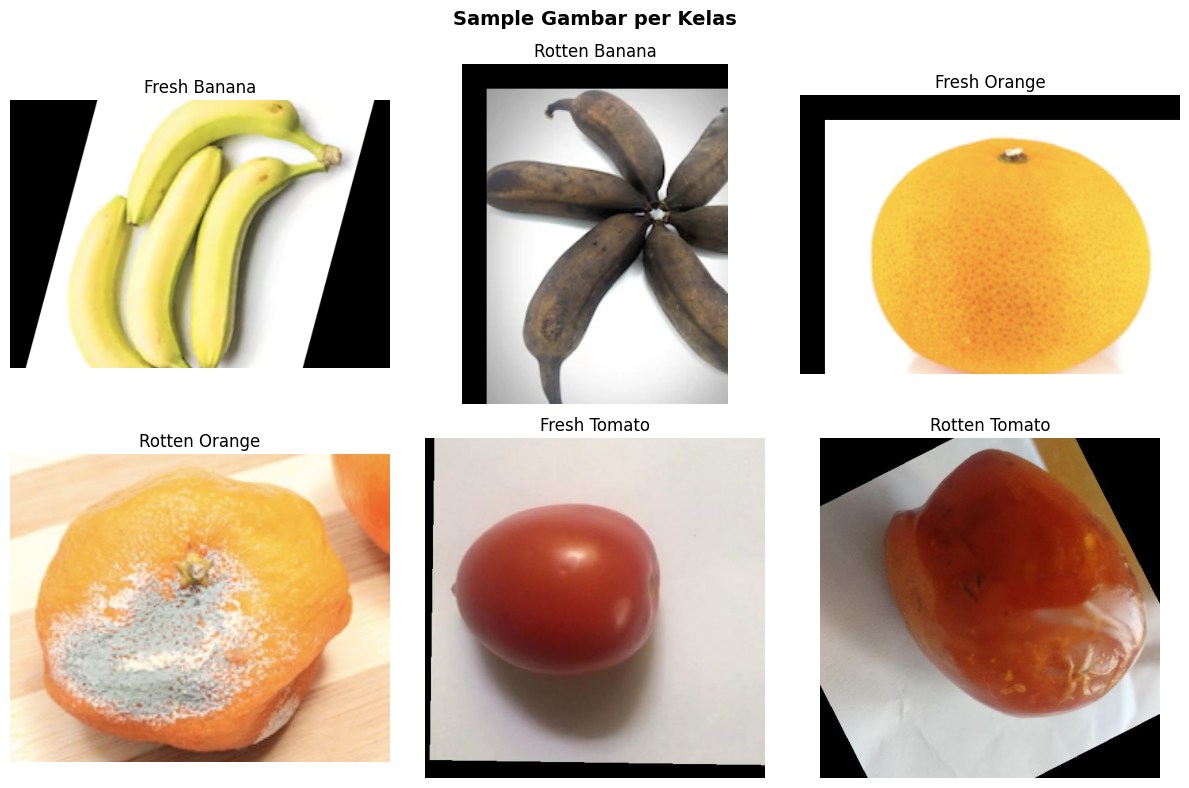

Tampilan sample gambar selesai!


In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

classes = {
    'Fresh Banana'  : '/content/datasets/sriramr/dataset/dataset/train/freshbanana',
    'Rotten Banana' : '/content/datasets/sriramr/dataset/dataset/train/rottenbanana',
    'Fresh Orange'  : '/content/datasets/sriramr/dataset/dataset/train/freshoranges',
    'Rotten Orange' : '/content/datasets/sriramr/dataset/dataset/train/rottenoranges',
    'Fresh Tomato'  : '/content/datasets/raghavrpotdar/fresh_tomato',
    'Rotten Tomato' : '/content/datasets/raghavrpotdar/stale_tomato',
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, (label, path) in enumerate(classes.items()):
    images = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random_img = random.choice(images)

    img = mpimg.imread(os.path.join(path, random_img))
    axes[idx].imshow(img)
    axes[idx].set_title(label, fontsize=12)
    axes[idx].axis('off')

plt.suptitle('Sample Gambar per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Tampilan sample gambar selesai!")

### Filter, Seleksi & Standarisasi Label — Multiclass

Karena kita sekarang memakai **6 kelas terpisah** (freshbanana, rottenbanana, freshorange, rottenorange, freshtomato, rottentomato), setiap kelas mendapat folder sendiri. Ini memungkinkan model tidak hanya mendeteksi segar/busuk tapi juga **jenis buahnya**.


In [11]:
import os
import shutil

base_output = '/content/datasets/final'

# 6 kelas multiclass
CLASSES = ['freshbanana', 'rottenbanana', 'freshorange', 'rottenorange', 'freshtomato', 'rottentomato']

for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        os.makedirs(f'{base_output}/{split}/{cls}', exist_ok=True)

print("Struktur folder final (multiclass) berhasil dibuat!")
print("\nStruktur yang dibuat:")
for split in ['train', 'val', 'test']:
    print(f"  final/{split}/")
    for cls in CLASSES:
        print(f"    {cls}/")


Struktur folder final (multiclass) berhasil dibuat!

Struktur yang dibuat:
  final/train/
    freshbanana/
    rottenbanana/
    freshorange/
    rottenorange/
    freshtomato/
    rottentomato/
  final/val/
    freshbanana/
    rottenbanana/
    freshorange/
    rottenorange/
    freshtomato/
    rottentomato/
  final/test/
    freshbanana/
    rottenbanana/
    freshorange/
    rottenorange/
    freshtomato/
    rottentomato/


#### **Mengcopy gambar ke folder final (6 kelas terpisah):**

In [12]:
import uuid
import shutil

def copy_images(src_folder, dst_folder):
    images = [f for f in os.listdir(src_folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for img_name in images:
        src_path = os.path.join(src_folder, img_name)
        new_name = f"{uuid.uuid4().hex}.jpg"
        dst_path = os.path.join(dst_folder, new_name)
        shutil.copy2(src_path, dst_path)
    return len(images)

sriramr_train = '/content/datasets/sriramr/dataset/dataset/train'
sriramr_test  = '/content/datasets/sriramr/dataset/dataset/test'
raghavrpotdar_base = '/content/datasets/raghavrpotdar'

# ── SRIRAMR Train → masing-masing kelas
mapping_sriramr_train = {
    'freshbanana'   : 'freshbanana',
    'rottenbanana'  : 'rottenbanana',
    'freshoranges'  : 'freshorange',
    'rottenoranges' : 'rottenorange',
}
print("=== Menyalin SRIRAMR (Train) ===")
for folder, cls in mapping_sriramr_train.items():
    src = os.path.join(sriramr_train, folder)
    dst = os.path.join(base_output, 'train', cls)
    count = copy_images(src, dst)
    print(f"  {folder} → train/{cls}: {count} gambar")

# ── SRIRAMR Test → masing-masing kelas
mapping_sriramr_test = {
    'freshbanana'   : 'freshbanana',
    'rottenbanana'  : 'rottenbanana',
    'freshoranges'  : 'freshorange',
    'rottenoranges' : 'rottenorange',
}
print("\n=== Menyalin SRIRAMR (Test) ===")
for folder, cls in mapping_sriramr_test.items():
    src = os.path.join(sriramr_test, folder)
    dst = os.path.join(base_output, 'test', cls)
    count = copy_images(src, dst)
    print(f"  {folder} → test/{cls}: {count} gambar")

# ── RAGHAVRPOTDAR (Tomat) → fresh_tomato & stale_tomato → freshtomato & rottentomato
mapping_raghavrpotdar = {
    'fresh_tomato' : 'freshtomato',
    'stale_tomato' : 'rottentomato',
}
print("\n=== Menyalin RAGHAVRPOTDAR (Tomat) ===")
for folder, cls in mapping_raghavrpotdar.items():
    src = os.path.join(raghavrpotdar_base, folder)
    dst = os.path.join(base_output, 'train', cls)
    count = copy_images(src, dst)
    print(f"  {folder} → train/{cls}: {count} gambar")

print("\nSemua gambar berhasil disalin ke 6 kelas terpisah!")


=== Menyalin SRIRAMR (Train) ===
  freshbanana → train/freshbanana: 1581 gambar
  rottenbanana → train/rottenbanana: 2224 gambar
  freshoranges → train/freshorange: 1466 gambar
  rottenoranges → train/rottenorange: 1595 gambar

=== Menyalin SRIRAMR (Test) ===
  freshbanana → test/freshbanana: 381 gambar
  rottenbanana → test/rottenbanana: 530 gambar
  freshoranges → test/freshorange: 388 gambar
  rottenoranges → test/rottenorange: 403 gambar

=== Menyalin RAGHAVRPOTDAR (Tomat) ===
  fresh_tomato → train/freshtomato: 981 gambar
  stale_tomato → train/rottentomato: 982 gambar

Semua gambar berhasil disalin ke 6 kelas terpisah!


Setiap buah sekarang punya folder kelas sendiri — 6 total:
- **freshbanana / rottenbanana** (dari sriramr)
- **freshorange / rottenorange** (dari sriramr, folder nama aslinya `freshoranges/rottenoranges` di-rename)
- **freshtomato / rottentomato** (dari raghavrpotdar, `stale` → `rotten`)

Dataset raghavrpotdar (tomat) belum punya split test, jadi semua tomat masuk ke `train/` dulu dan akan di-split manual di langkah berikutnya.


#### **Mengecek Distribusi Gambar Setelah Proses Copy sebelumnya**

In [13]:
print("=== DISTRIBUSI FOLDER FINAL (setelah copy) ===")
total = 0
for split in ['train', 'val', 'test']:
    print(f"\n{split}/")
    split_total = 0
    for cls in CLASSES:
        path = f'{base_output}/{split}/{cls}'
        count = len([f for f in os.listdir(path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {cls}: {count} gambar")
        total += count
        split_total += count
    print(f"  Subtotal: {split_total} gambar")

print(f"\nTotal keseluruhan: {total} gambar")
print("(val masih kosong — akan diisi saat split berikutnya)")


=== DISTRIBUSI FOLDER FINAL (setelah copy) ===

train/
  freshbanana: 1581 gambar
  rottenbanana: 2224 gambar
  freshorange: 1466 gambar
  rottenorange: 1595 gambar
  freshtomato: 981 gambar
  rottentomato: 982 gambar
  Subtotal: 8829 gambar

val/
  freshbanana: 0 gambar
  rottenbanana: 0 gambar
  freshorange: 0 gambar
  rottenorange: 0 gambar
  freshtomato: 0 gambar
  rottentomato: 0 gambar
  Subtotal: 0 gambar

test/
  freshbanana: 381 gambar
  rottenbanana: 530 gambar
  freshorange: 388 gambar
  rottenorange: 403 gambar
  freshtomato: 0 gambar
  rottentomato: 0 gambar
  Subtotal: 1702 gambar

Total keseluruhan: 10531 gambar
(val masih kosong — akan diisi saat split berikutnya)


Terlihat bahwa `val/` masih kosong dan tomat hanya ada di `train/`. Langkah berikutnya adalah split 15% dari masing-masing kelas di `train/` ke `val/`, dan juga membuat test set untuk tomat (karena raghavrpotdar tidak punya split test bawaan).


#### **Split Data dan Memindahkan Gambar Tomat**

In [14]:
import random
import shutil

def move_images_pct(src_folder, dst_folder, pct=0.15, seed=42):
    images = [f for f in os.listdir(src_folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.seed(seed)
    n = int(len(images) * pct)
    selected = random.sample(images, n)
    for img_name in selected:
        shutil.move(os.path.join(src_folder, img_name),
                    os.path.join(dst_folder, img_name))
    return n

print("=== Split 15% dari setiap kelas → Val ===")
for cls in CLASSES:
    n = move_images_pct(
        f'{base_output}/train/{cls}',
        f'{base_output}/val/{cls}',
        pct=0.15
    )
    print(f"  {cls}: {n} gambar dipindah ke val/")

# Tomat tidak punya test split bawaan → ambil 15% dari train untuk test
print("\n=== Split 15% tomat dari Train → Test ===")
for cls in ['freshtomato', 'rottentomato']:
    n = move_images_pct(
        f'{base_output}/train/{cls}',
        f'{base_output}/test/{cls}',
        pct=0.15
    )
    print(f"  {cls}: {n} gambar dipindah ke test/")

print("\nSplit selesai!")


=== Split 15% dari setiap kelas → Val ===
  freshbanana: 237 gambar dipindah ke val/
  rottenbanana: 333 gambar dipindah ke val/
  freshorange: 219 gambar dipindah ke val/
  rottenorange: 239 gambar dipindah ke val/
  freshtomato: 147 gambar dipindah ke val/
  rottentomato: 147 gambar dipindah ke val/

=== Split 15% tomat dari Train → Test ===
  freshtomato: 125 gambar dipindah ke test/
  rottentomato: 125 gambar dipindah ke test/

Split selesai!


Split dilakukan **per kelas** agar distribusi tiap kelas tetap proporsional di semua split. 15% dari tiap kelas di `train/` dipindah ke `val/`, dan untuk tomat 15% tambahan dipindah ke `test/` (karena tidak ada split bawaan).


#### **Mengecek Distribusi Final Dataset**

In [15]:
print("=== DISTRIBUSI FINAL DATASET (6 Kelas) ===")
grand_total = 0
for split in ['train', 'val', 'test']:
    print(f"\n{split}/")
    split_total = 0
    for cls in CLASSES:
        path = f'{base_output}/{split}/{cls}'
        count = len([f for f in os.listdir(path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {cls}: {count} gambar")
        grand_total += count
        split_total += count
    print(f"  Subtotal: {split_total} gambar")

print(f"\nGrand total: {grand_total} gambar")


=== DISTRIBUSI FINAL DATASET (6 Kelas) ===

train/
  freshbanana: 1344 gambar
  rottenbanana: 1891 gambar
  freshorange: 1247 gambar
  rottenorange: 1356 gambar
  freshtomato: 709 gambar
  rottentomato: 710 gambar
  Subtotal: 7257 gambar

val/
  freshbanana: 237 gambar
  rottenbanana: 333 gambar
  freshorange: 219 gambar
  rottenorange: 239 gambar
  freshtomato: 147 gambar
  rottentomato: 147 gambar
  Subtotal: 1322 gambar

test/
  freshbanana: 381 gambar
  rottenbanana: 530 gambar
  freshorange: 388 gambar
  rottenorange: 403 gambar
  freshtomato: 125 gambar
  rottentomato: 125 gambar
  Subtotal: 1952 gambar

Grand total: 10531 gambar


Dataset final terdiri dari **6 kelas** yang dibagi ke tiga split (train/val/test). Model akan belajar mengenali jenis buah **sekaligus** kondisi kesegarannya dalam satu prediksi.


### Preprocessing

#### **Resize, Normalisasi & Augmentasi**

- Resize → MobileNetV2 hanya menerima input gambar ukuran 224×224 dan gambar dari dataset yang ada itu punya ukuran yang berbeda-beda, jadi harus diseragamkan
- Normalisasi → pixel value asli gambar berkisar 0–255, jadi akan diubah ke 0–1 agar model lebih mudah dan cepat belajar
- Augmentasi → khusus data train, akan ditambah variasi gambar secara artifisial (flip, rotasi, brightness) agar model lebih robust dan tidak overfitting

#### **Konfigurasi ImageDataGenerator**

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentasi hanya diterapkan ke train, bukan val dan test
# karena val dan test digunakan untuk evaluasi kondisi nyata
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("ImageDataGenerator berhasil dikonfigurasi!")

ImageDataGenerator berhasil dikonfigurasi!


- **train_datagen** (untuk training) selain normalisasi pixel ke rentang 0–1, juga menerapkan augmentasi data: flip horizontal, rotasi ±15°, variasi kecerahan 80–120%, dan zoom 10%. Augmentasi ini membuat model lebih robust dengan melihat variasi gambar yang lebih beragam.
- **val_test_datagen** (untuk validasi & test) hanya normalisasi saja, tanpa augmentasi. Ini penting agar evaluasi dilakukan pada kondisi gambar yang natural/asli.

#### **Load dataset menggunakan generator**

In [17]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    f'{base_output}/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # multiclass
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    f'{base_output}/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

test_generator = val_test_datagen.flow_from_directory(
    f'{base_output}/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print(f"Class indices: {train_generator.class_indices}")
print(f"Jumlah kelas : {train_generator.num_classes}")
for name, idx in sorted(train_generator.class_indices.items(), key=lambda x: x[1]):
    print(f"  {idx}: {name}")


Found 7257 images belonging to 6 classes.
Found 1322 images belonging to 6 classes.
Found 1952 images belonging to 6 classes.
Class indices: {'freshbanana': 0, 'freshorange': 1, 'freshtomato': 2, 'rottenbanana': 3, 'rottenorange': 4, 'rottentomato': 5}
Jumlah kelas : 6
  0: freshbanana
  1: freshorange
  2: freshtomato
  3: rottenbanana
  4: rottenorange
  5: rottentomato


`class_mode='categorical'` digunakan karena kita punya 6 kelas. Generator akan menghasilkan label one-hot encoded (misal: `[0,0,1,0,0,0]` untuk kelas ke-2). Urutan kelas diurutkan alfabetis oleh Keras.


#### **Hasil Preprocessing Secara Visual**

=== VERIFIKASI PREPROCESSING ===
Shape images: (32, 224, 224, 3)  (batch x 224 x 224 x 3)
Shape labels: (32, 6)  (batch x 6, one-hot)
Pixel min: 0.0000  max: 1.0000

Distribusi label dalam batch ini:
  0 (freshbanana): 6 gambar
  1 (freshorange): 7 gambar
  2 (freshtomato): 5 gambar
  3 (rottenbanana): 5 gambar
  4 (rottenorange): 6 gambar
  5 (rottentomato): 3 gambar


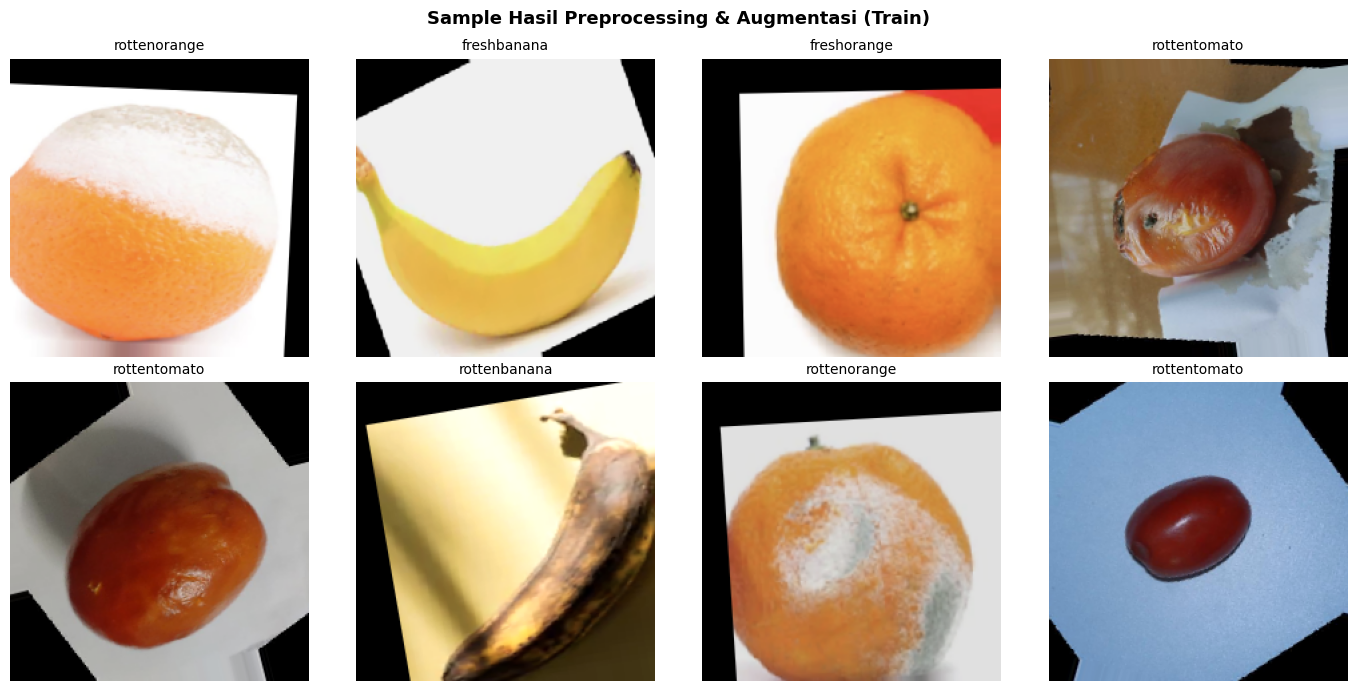

In [18]:
import numpy as np

images, labels = next(train_generator)

idx_to_class = {v: k for k, v in train_generator.class_indices.items()}

print("=== VERIFIKASI PREPROCESSING ===")
print(f"Shape images: {images.shape}  (batch x 224 x 224 x 3)")
print(f"Shape labels: {labels.shape}  (batch x 6, one-hot)")
print(f"Pixel min: {images.min():.4f}  max: {images.max():.4f}")
print(f"\nDistribusi label dalam batch ini:")
label_ids = np.argmax(labels, axis=1)
for i in range(6):
    count = (label_ids == i).sum()
    print(f"  {i} ({idx_to_class[i]}): {count} gambar")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for i in range(8):
    axes[i].imshow(images[i])
    cls_name = idx_to_class[np.argmax(labels[i])]
    axes[i].set_title(cls_name, fontsize=10)
    axes[i].axis('off')
plt.suptitle('Sample Hasil Preprocessing & Augmentasi (Train)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Training Model

### Mount Google Drive & Setup

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/CekFresh_Model'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Model akan disimpan ke: {SAVE_DIR}")

Mounted at /content/drive
✅ Model akan disimpan ke: /content/drive/MyDrive/CekFresh_Model


### Membangun Arsitektur Model MobileNetV2 — Multiclass (6 Kelas)

Menggunakan Transfer Learning dengan MobileNetV2 pre-trained ImageNet. Output layer diganti menjadi `Dense(6, softmax)` untuk klasifikasi 6 kelas (jenis buah + kondisi kesegaran). Loss function: `categorical_crossentropy`.


In [20]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

IMG_SHAPE  = (224, 224, 3)
NUM_CLASSES = 6   # freshbanana, rottenbanana, freshorange, rottenorange, freshtomato, rottentomato

# Load MobileNetV2 pretrained ImageNet, tanpa top layer
base_model = MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # Freeze semua layer (Phase 1)

# Bangun classifier di atas base_model
inputs  = tf.keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)   # 6-class softmax

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\nTotal params     : {model.count_params():,}")
print(f"Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"\n✅ Model multiclass ({NUM_CLASSES} kelas) berhasil dibangun!")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total params     : 2,587,462
Trainable params : 329,478

✅ Model multiclass (6 kelas) berhasil dibangun!


### Phase 1 — Training (Base Model Frozen)

Pada fase ini, seluruh layer MobileNetV2 di-freeze dan hanya layer classifier baru yang dilatih. Tujuannya agar layer classifier baru menyesuaikan diri dengan fitur yang sudah dipelajari MobileNetV2 dari ImageNet.

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(
        filepath=f'{SAVE_DIR}/cekfresh_multiclass_phase1_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print("=" * 60)
print("  PHASE 1 — Training (base model frozen, 6 kelas)")
print("=" * 60)

history_p1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks_p1,
    verbose=1
)

print(f"\n✅ Phase 1 selesai!")
print(f"   Best val_accuracy : {max(history_p1.history['val_accuracy']):.4f}")


  PHASE 1 — Training (base model frozen, 6 kelas)
Epoch 1/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.8845 - loss: 0.3086
Epoch 1: val_accuracy improved from None to 0.97201, saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_multiclass_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_multiclass_phase1_best.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 172s 673ms/step - accuracy: 0.9467 - loss: 0.1400 - val_accuracy: 0.9720 - val_loss: 0.0582 - learning_rate: 0.0010
Epoch 2/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.9809 - loss: 0.0549
Epoch 2: val_accuracy improved from 0.97201 to 0.98185, saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_multiclass_phase1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_multiclass_phase1_best.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 123s 543ms/step - accuracy: 0.9824 - loss: 0.0503 - val_accuracy: 0.9818 - val_loss: 

### Phase 2 — Fine-tuning (Unfreeze 30 Layer Terakhir)

Pada fase ini, 30 layer terakhir MobileNetV2 di-unfreeze dan dilatih ulang dengan learning rate yang sangat kecil (1e-5) agar model dapat menyesuaikan fitur-fitur tingkat tinggi yang spesifik terhadap dataset buah dan sayur.

In [22]:
# Unfreeze 30 layer terakhir base_model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile dengan learning rate lebih kecil
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable params setelah unfreeze: {trainable_count:,}")

callbacks_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(
        filepath=f'{SAVE_DIR}/cekfresh_multiclass_phase2_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print("=" * 60)
print("  PHASE 2 — Fine-tuning (30 layer terakhir, 6 kelas)")
print("=" * 60)

history_p2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks_p2,
    verbose=1
)

print(f"\n✅ Phase 2 selesai!")
print(f"   Best val_accuracy : {max(history_p2.history['val_accuracy']):.4f}")


Trainable params setelah unfreeze: 1,855,878
  PHASE 2 — Fine-tuning (30 layer terakhir, 6 kelas)
Epoch 1/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.8190 - loss: 0.6802
Epoch 1: val_accuracy improved from None to 0.99319, saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_multiclass_phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_multiclass_phase2_best.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 156s 614ms/step - accuracy: 0.9067 - loss: 0.3174 - val_accuracy: 0.9932 - val_loss: 0.0189 - learning_rate: 1.0000e-05
Epoch 2/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.9760 - loss: 0.0659
Epoch 2: val_accuracy did not improve from 0.99319
227/227 ━━━━━━━━━━━━━━━━━━━━ 123s 544ms/step - accuracy: 0.9764 - loss: 0.0636 - val_accuracy: 0.9932 - val_loss: 0.0171 - learning_rate: 1.0000e-05
Epoch 3/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.9818 - loss: 0.0483
Epoch 3: val_accuracy did not imp

### Menyimpan Model Final ke Google Drive

In [23]:
import json

# Simpan model final
model_path = f'{SAVE_DIR}/cekfresh_model.keras'
model.save(model_path)
print(f"✅ Model disimpan  : {model_path}")

# Simpan class names — format: {"0": "freshbanana", "1": "freshorange", ...}
class_names = {str(v): k for k, v in train_generator.class_indices.items()}
with open(f'{SAVE_DIR}/class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)

print(f"\n✅ class_names.json disimpan")
print(f"   Isi:")
for k, v in sorted(class_names.items(), key=lambda x: int(x[0])):
    print(f"   {k}: {v}")

print(f"\nSemua file ada di Google Drive: {SAVE_DIR}/")


✅ Model disimpan  : /content/drive/MyDrive/CekFresh_Model/cekfresh_model.keras

✅ class_names.json disimpan
   Isi:
   0: freshbanana
   1: freshorange
   2: freshtomato
   3: rottenbanana
   4: rottenorange
   5: rottentomato

Semua file ada di Google Drive: /content/drive/MyDrive/CekFresh_Model/


### Visualisasi Training History

Menampilkan kurva Accuracy dan Loss dari Phase 1 dan Phase 2 digabungkan untuk melihat perkembangan performa model selama training.

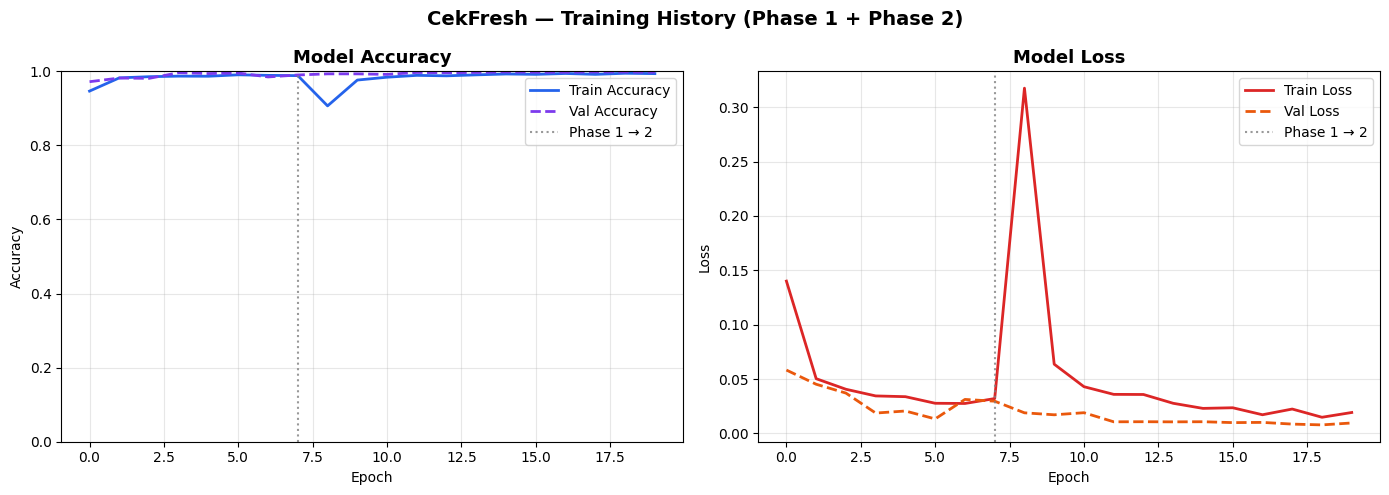

✅ Grafik disimpan: accuracy_loss_curve.png


In [24]:
import matplotlib.pyplot as plt

# Gabungkan history Phase 1 + Phase 2
history_all = {}
for key in history_p1.history:
    history_all[key] = history_p1.history[key] + history_p2.history[key]

phase1_end = len(history_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# -- Accuracy --
ax1.plot(history_all['accuracy'],     label='Train Accuracy', color='#2563eb', linewidth=2)
ax1.plot(history_all['val_accuracy'], label='Val Accuracy',   color='#7c3aed', linewidth=2, linestyle='--')
ax1.axvline(x=phase1_end - 1, color='gray', linestyle=':', alpha=0.8, label='Phase 1 → 2')
ax1.set_title('Model Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim([0, 1])

# -- Loss --
ax2.plot(history_all['loss'],     label='Train Loss', color='#dc2626', linewidth=2)
ax2.plot(history_all['val_loss'], label='Val Loss',   color='#ea580c', linewidth=2, linestyle='--')
ax2.axvline(x=phase1_end - 1, color='gray', linestyle=':', alpha=0.8, label='Phase 1 → 2')
ax2.set_title('Model Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('CekFresh — Training History (Phase 1 + Phase 2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/accuracy_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan: accuracy_loss_curve.png")

### Evaluasi Model pada Test Set

Mengevaluasi performa model pada data test yang belum pernah dilihat model selama training. Menampilkan classification report dan confusion matrix.

Mengevaluasi model pada test set...
61/61 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step

  TEST ACCURACY  : 0.9954  (99.54%)

Classification Report:
              precision    recall  f1-score   support

 freshbanana       1.00      1.00      1.00       381
 freshorange       0.99      0.99      0.99       388
 freshtomato       0.98      0.98      0.98       125
rottenbanana       1.00      1.00      1.00       530
rottenorange       1.00      0.99      0.99       403
rottentomato       0.98      0.98      0.98       125

    accuracy                           1.00      1952
   macro avg       0.99      0.99      0.99      1952
weighted avg       1.00      1.00      1.00      1952

✅ Classification report disimpan


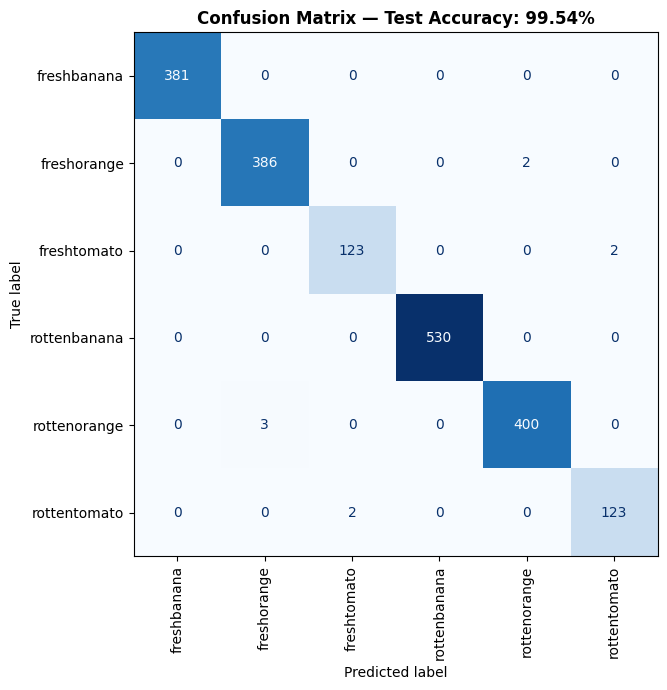

✅ Confusion matrix disimpan

  FILE TERSIMPAN DI GOOGLE DRIVE:
  /content/drive/MyDrive/CekFresh_Model/
    ├── cekfresh_model.keras
    ├── class_names.json
    ├── accuracy_loss_curve.png
    ├── confusion_matrix.png
    └── classification_report.txt


In [25]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
import numpy as np
import matplotlib.pyplot as plt

print("Mengevaluasi model pada test set...")
test_generator.reset()

y_pred_prob = model.predict(test_generator, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)   # multiclass: ambil index terbesar
y_true      = test_generator.classes

# Accuracy
test_acc = accuracy_score(y_true, y_pred)
print(f"\n{'='*55}")
print(f"  TEST ACCURACY  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*55}")

# Label names
class_labels = [name for name, _ in sorted(
    train_generator.class_indices.items(), key=lambda x: x[1])]

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_labels)
print("\nClassification Report:")
print(report)

# Simpan report
with open(f'{SAVE_DIR}/classification_report.txt', 'w') as f:
    f.write(f"CekFresh Multiclass — Classification Report\n")
    f.write(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)\n\n")
    f.write(report)
print("✅ Classification report disimpan")

# Confusion Matrix
cm   = confusion_matrix(y_true, y_pred)
fig2, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation='vertical')
ax.set_title(f'Confusion Matrix — Test Accuracy: {test_acc*100:.2f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix disimpan")

print(f"\n{'='*55}")
print("  FILE TERSIMPAN DI GOOGLE DRIVE:")
print(f"  {SAVE_DIR}/")
print("    ├── cekfresh_model.keras")
print("    ├── class_names.json")
print("    ├── accuracy_loss_curve.png")
print("    ├── confusion_matrix.png")
print("    └── classification_report.txt")
print(f"{'='*55}")
